In [5]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss
import lightgbm as lgb
import matplotlib.pyplot as plt

# Charger le dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset chargé ✅")
print(f"Nombre de patients : {X.shape[0]}")
print(f"Nombre de features : {X.shape[1]}")
print(f"Bénin (1): {y.sum()} | Malin (0): {(y==0).sum()}")

Dataset chargé ✅
Nombre de patients : 569
Nombre de features : 30
Bénin (1): 357 | Malin (0): 212


In [7]:
# Normalisation
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split train/test
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Modèle LightGBM
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val,   label=y_val)

params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": ["auc", "binary_logloss"],
    "num_leaves": 31,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "seed": 42,
    "verbose": -1,
}

model = lgb.train(
    params,
    dtrain,
    valid_sets=[dtrain, dval],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print("\nEntraînement terminé ✅")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[34]	training's auc: 0.99839	training's binary_logloss: 0.148044	valid_1's auc: 0.993056	valid_1's binary_logloss: 0.18186

Entraînement terminé ✅


=== Résultats ===
AUC      : 0.9931
Log Loss : 0.1819
Accuracy : 0.9474


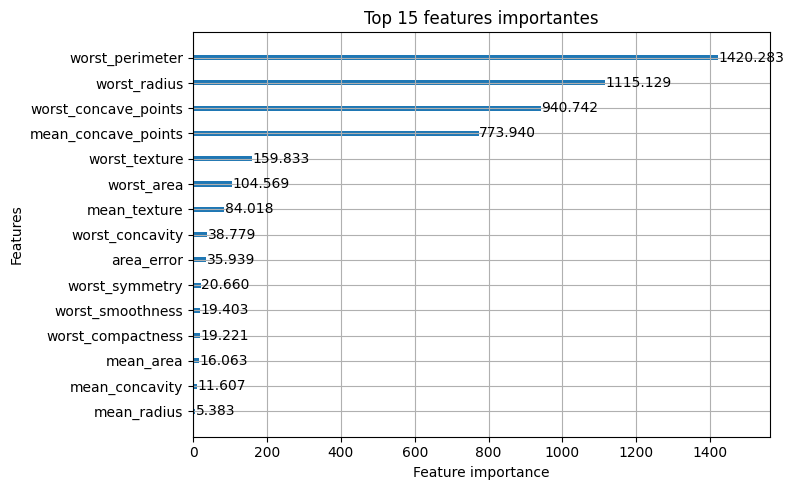

In [8]:
y_pred_proba = model.predict(X_val)
y_pred_class = (y_pred_proba > 0.5).astype(int)

print("=== Résultats ===")
print(f"AUC      : {roc_auc_score(y_val, y_pred_proba):.4f}")
print(f"Log Loss : {log_loss(y_val, y_pred_proba):.4f}")
print(f"Accuracy : {accuracy_score(y_val, y_pred_class):.4f}")

lgb.plot_importance(model, max_num_features=15, importance_type="gain", figsize=(8,5))
plt.title("Top 15 features importantes")
plt.tight_layout()
plt.show()

In [9]:
import joblib

# Sauvegarder le modèle
joblib.dump(model, 'cancer_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Modèle sauvegardé ✅")
print("Fichiers créés : cancer_model.pkl et scaler.pkl")


Modèle sauvegardé ✅
Fichiers créés : cancer_model.pkl et scaler.pkl
